# Accuracy evaluation of Flash Attention

测试C算子与PyTorch官方实现的单头Attention Outputs精度偏差

Parameters：

- `SEQ_LEN`: 128, 256, 512, 1024, 250(for padding)
- `BR*BC`: 64\*64, 128\*128
- `HEAD_DIM`: 64

Evaluation Metrics:

- Cosine Similarity
- Relative Error
- Maximum Absolute Error

Visualization:

- Error Heatmap / Curve
- Similarity Curve per Token
- Output Value Distribution

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from typing import Tuple, Dict, List, Optional
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
class AttentionOutput:
    """
    表示单个Attention输出文件并提供加载与误差评估工具

    Args:
        path (str): 输出文件路径，文件名格式应当为"O_{model}_seq{seq_len}_brbc{br}x{bc}.txt"

    Attributes:
        path (Path): 文件路径对象
        file_name (str): 文件名含后缀
        model (str): 模型标识从文件名解析
        seq_len (int): 序列长度从文件名解析
        tile_shape (Tuple[int, int]): 分块形状从文件名解析
        head_dim (int): 头维度
        tensor (torch.Tensor): 输出张量
        shape (Tuple[int, ...]): 张量形状
    """
    def __init__(self, path: str) -> None:
        self.path: Path = Path(path)
        self.file_name: str = self.path.name
        self.model: str = self.path.stem.split("_")[1]
        self.seq_len: int = int(self.path.stem.split("_")[2].replace("seq", ""))
        tile_shape_str = self.path.stem.split("_")[3].replace("brbc", "")
        self.tile_shape: Tuple = tuple(map(int, tile_shape_str.split("x")))
        self.head_dim: int = 64
        self.tensor: torch.Tensor = torch.empty(0)
        self.tensor = self.load_tensor()
        self.shape: Tuple = self.tensor.shape

    def load_tensor(self) -> torch.Tensor:
        """
        从文件读取并缓存输出张量
        Returns:
            torch.Tensor: 读取到的输出张量
        """
        if self.tensor.numel() != 0:
            return self.tensor
        
        if self.path.is_file():
            with self.path.open("r", encoding="utf-8") as f:
                lines = f.read().strip().split("\n\n")
                self.tensor = torch.tensor([list(map(float, line.split())) for line in lines], dtype=torch.float32)
        else:
            raise FileNotFoundError(f"File {self.path} does not exist.")

        return self.tensor
    
    def cos_similarity(self, target: "AttentionOutput") -> torch.Tensor:
        """
        计算与目标输出的逐Token余弦相似度
        Args:
            target (AttentionOutput): 目标参考输出对象
        Returns:
            torch.Tensor: 逐Token余弦相似度
        """    
        if self.shape != target.shape:
            raise ValueError(f"Shape mismatch: {self.shape} vs {target.shape}")
        
        return F.cosine_similarity(self.tensor, target.tensor)
    
    def relative_error(self, target: "AttentionOutput") -> Tuple[float, torch.Tensor]:
        """
        计算输入矩阵的逐Token和Tensor Level相对误差（基于Frobenius 范数）
        Args:
            target (AttentionOutput): 目标参考输出对象
        Returns:
            Tuple[float, torch.Tensor]: 返回一个元组，包含整体矩阵的相对误差和逐Token的相对误差
        """
        if self.shape != target.shape:
            raise ValueError(f"Shape mismatch: {self.shape} vs {target.shape}")
        
        eps = 1e-9
        # Per tensor
        tensor_diff = torch.linalg.matrix_norm(self.tensor - target.tensor)
        tensor_target_norm = torch.linalg.matrix_norm(target.tensor)
        tensor_relative_error = tensor_diff / (tensor_target_norm + eps)
        # Per token
        token_diff = torch.linalg.norm(self.tensor - target.tensor, dim=1)
        token_target_norm = torch.linalg.norm(target.tensor, dim=1)
        token_relative_error = token_diff / (token_target_norm + eps)

        return tensor_relative_error.item(), token_relative_error
    
    def max_abs_error(self, target: "AttentionOutput") -> Tuple[float, torch.Tensor]:
        """
        计算输入矩阵的逐Token和Tensor Level最大绝对误差
        Args:
            target (AttentionOutput): 目标参考输出对象
        Returns:
            Tuple[float, torch.Tensor]: 返回一个元组，包含整体矩阵的最大绝对误差和逐Token的最大绝对误差
        """
        if self.shape != target.shape:
            raise ValueError(f"Shape mismatch: {self.shape} vs {target.shape}")
        
        return torch.max((self.tensor - target.tensor).abs()).item(), torch.max((self.tensor - target.tensor).abs(), dim=1).values


In [3]:
O_c = {}
O_python = {}
O_golden = {}

for file in Path("data/single_head_outputs/").glob("O_c_*.txt"):
    O_c[file.stem.split("O_c_")[1]] = AttentionOutput(str(file))

for file in Path("data/single_head_outputs/").glob("O_python_*.txt"):
    O_python[file.stem.split("O_python_")[1]] = AttentionOutput(str(file))

for file in Path("data/single_head_outputs/").glob("O_golden_*.txt"):
    O_golden[file.stem.split("O_golden_")[1]] = AttentionOutput(str(file))

O_c, O_python, O_golden

({'seq1024_brbc128x128': <__main__.AttentionOutput at 0x25f06e05e80>,
  'seq1024_brbc64x64': <__main__.AttentionOutput at 0x25f7f3379d0>,
  'seq128_brbc128x128': <__main__.AttentionOutput at 0x25f7f337890>,
  'seq128_brbc64x64': <__main__.AttentionOutput at 0x25f0b7708a0>,
  'seq250_brbc128x128': <__main__.AttentionOutput at 0x25f0b771810>,
  'seq250_brbc64x64': <__main__.AttentionOutput at 0x25f0b72ef90>,
  'seq256_brbc128x128': <__main__.AttentionOutput at 0x25f7f4dd590>,
  'seq256_brbc64x64': <__main__.AttentionOutput at 0x25f0bacf240>,
  'seq512_brbc128x128': <__main__.AttentionOutput at 0x25f0b871650>,
  'seq512_brbc64x64': <__main__.AttentionOutput at 0x25f0b871750>},
 {'seq1024_brbc128x128': <__main__.AttentionOutput at 0x25f7f328410>,
  'seq1024_brbc64x64': <__main__.AttentionOutput at 0x25f0b7624e0>,
  'seq128_brbc128x128': <__main__.AttentionOutput at 0x25f0bd13150>,
  'seq128_brbc64x64': <__main__.AttentionOutput at 0x25f0baf9630>,
  'seq250_brbc128x128': <__main__.Attention

## Visualization

### 1. Similarity Curve per Token

取Sequence Length 1k, Br = Bc = 128情况下的逐Token余弦相似度

Mean Cosine Similarity (C vs Golden) (seq_len = 1024, br = 128, bc = 128, head_dim = 64): 0.999841


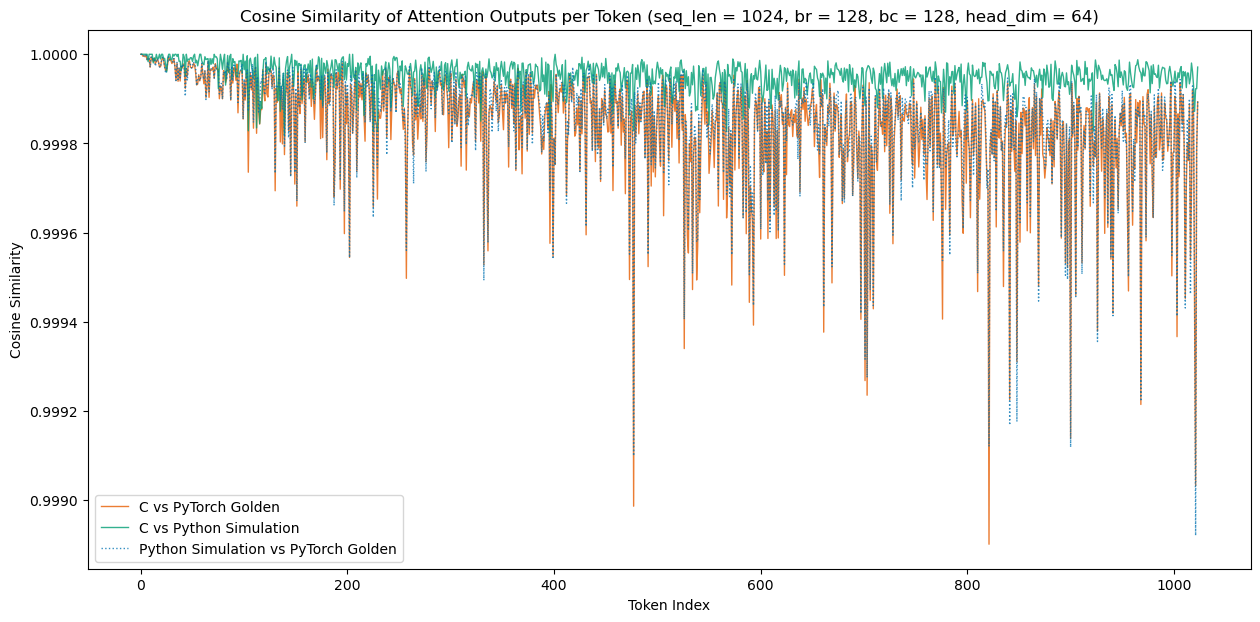

In [4]:
plt.figure(figsize=(15, 7))
plt.plot(O_c["seq1024_brbc128x128"].cos_similarity(O_golden["seq1024_brbc128x128"]), 
         label="C vs PyTorch Golden",
         linewidth=1.0,
         alpha=0.8,
         color="#E65C00")
plt.plot(O_c["seq1024_brbc128x128"].cos_similarity(O_python["seq1024_brbc128x128"]), 
         label="C vs Python Simulation",
         linewidth=1.0, 
         alpha=0.8,
         color="#009E73")
plt.plot(O_python["seq1024_brbc128x128"].cos_similarity(O_golden["seq1024_brbc128x128"]), 
         label="Python Simulation vs PyTorch Golden",
         linewidth=1.0,
         alpha=0.8,
         linestyle="dotted",
         color="#0072B2")
plt.xlabel("Token Index")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity of Attention Outputs per Token (seq_len = 1024, br = 128, bc = 128, head_dim = 64)")
plt.legend()

print(f"Mean Cosine Similarity (C vs Golden) (seq_len = 1024, br = 128, bc = 128, head_dim = 64): {O_c['seq1024_brbc128x128'].cos_similarity(O_golden['seq1024_brbc128x128']).mean().item():.6f}")

### 2. Error Curve

#### 2.1 Relative Error

- Sequence Length 1k, Br = Bc = 128情况下的逐token相对误差曲线
- Tensor Level相对误差随Sequence Length的变化曲线（固定Br = Bc = 128）

Tensor Level Relative Error (C vs Golden) (seq_len = 1024, br = 128, bc = 128, head_dim = 64): 0.011852


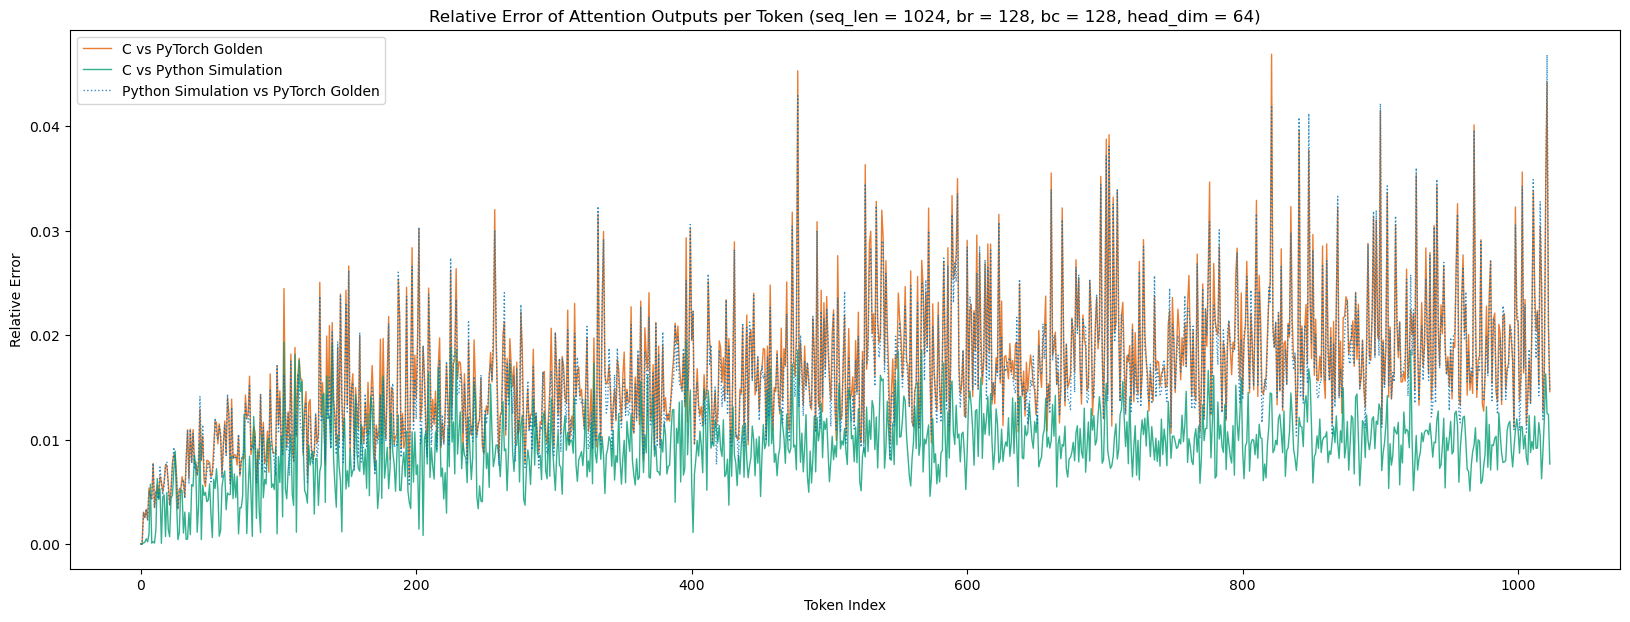

In [5]:
plt.figure(figsize=(20, 7))
plt.plot(O_c["seq1024_brbc128x128"].relative_error(O_golden["seq1024_brbc128x128"])[1],
         label="C vs PyTorch Golden",
         linewidth=1.0,
         alpha=0.8,
         color="#E65C00")
plt.plot(O_c["seq1024_brbc128x128"].relative_error(O_python["seq1024_brbc128x128"])[1],
         label="C vs Python Simulation",
         linewidth=1.0, 
         alpha=0.8,
         color="#009E73")
plt.plot(O_python["seq1024_brbc128x128"].relative_error(O_golden["seq1024_brbc128x128"])[1],
         label="Python Simulation vs PyTorch Golden",
         linewidth=1.0,
         alpha=0.8,
         linestyle="dotted",
         color="#0072B2")
plt.xlabel("Token Index")
plt.ylabel("Relative Error")
plt.title("Relative Error of Attention Outputs per Token (seq_len = 1024, br = 128, bc = 128, head_dim = 64)")
plt.legend()

print(f"Tensor Level Relative Error (C vs Golden) (seq_len = 1024, br = 128, bc = 128, head_dim = 64): {O_c['seq1024_brbc128x128'].relative_error(O_golden['seq1024_brbc128x128'])[0]:.6f}")

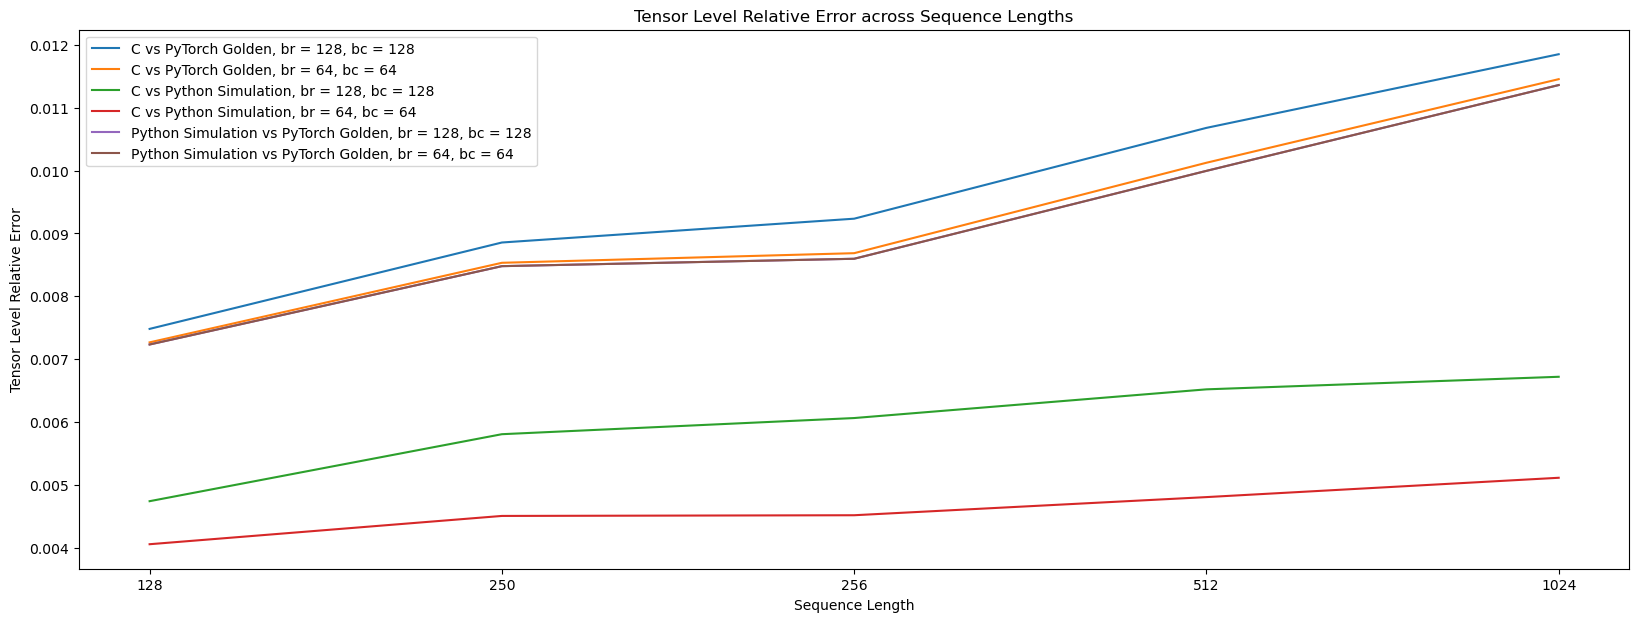

In [6]:
tensor_relative_error_c_golden_128x128 = {}
tensor_relative_error_c_golden_64x64 = {}
tensor_relative_error_c_python_128x128 = {}
tensor_relative_error_c_python_64x64 = {}
tensor_relative_error_python_golden_128x128 = {}
tensor_relative_error_python_golden_64x64 = {}

pairs = sorted(
    zip(O_c.items(), O_golden.items(), O_python.items()),
    key=lambda pair: int(pair[0][0].split("_")[0].replace("seq", ""))
)

for (k_c, v_c), (k_golden, v_golden), (k_python, v_python) in pairs:
    if "128x128" in k_c and k_c == k_golden == k_python:
        tensor_relative_error_c_golden_128x128[k_c.split("_")[0].replace("seq", "")] = v_c.relative_error(v_golden)[0]
        tensor_relative_error_c_python_128x128[k_c.split("_")[0].replace("seq", "")] = v_c.relative_error(v_python)[0]
        tensor_relative_error_python_golden_128x128[k_c.split("_")[0].replace("seq", "")] = v_python.relative_error(v_golden)[0]
    elif "64x64" in k_c and k_c == k_golden == k_python:
        tensor_relative_error_c_golden_64x64[k_c.split("_")[0].replace("seq", "")] = v_c.relative_error(v_golden)[0]
        tensor_relative_error_c_python_64x64[k_c.split("_")[0].replace("seq", "")] = v_c.relative_error(v_python)[0]
        tensor_relative_error_python_golden_64x64[k_c.split("_")[0].replace("seq", "")] = v_python.relative_error(v_golden)[0]

plt.figure(figsize=(20, 7))
plt.plot(list(tensor_relative_error_c_golden_128x128.keys()), list(tensor_relative_error_c_golden_128x128.values()),
         label="C vs PyTorch Golden, br = 128, bc = 128")
plt.plot(list(tensor_relative_error_c_golden_64x64.keys()), list(tensor_relative_error_c_golden_64x64.values()),
         label="C vs PyTorch Golden, br = 64, bc = 64")
plt.plot(list(tensor_relative_error_c_python_128x128.keys()), list(tensor_relative_error_c_python_128x128.values()),
         label="C vs Python Simulation, br = 128, bc = 128")
plt.plot(list(tensor_relative_error_c_python_64x64.keys()), list(tensor_relative_error_c_python_64x64.values()),
         label="C vs Python Simulation, br = 64, bc = 64")
plt.plot(list(tensor_relative_error_python_golden_128x128.keys()), list(tensor_relative_error_python_golden_128x128.values()),
         label="Python Simulation vs PyTorch Golden, br = 128, bc = 128")
plt.plot(list(tensor_relative_error_python_golden_64x64.keys()), list(tensor_relative_error_python_golden_64x64.values()),
         label="Python Simulation vs PyTorch Golden, br = 64, bc = 64")
plt.xlabel("Sequence Length")
plt.ylabel("Tensor Level Relative Error")
plt.title("Tensor Level Relative Error across Sequence Lengths")
plt.legend()

#### 2.2 Max Absolute Error

与Relative Error可视化条件相同

Tensor Level Max Absolute Error (C vs Golden) (seq_len = 1024, br = 128, bc = 128, head_dim = 64): 0.019475


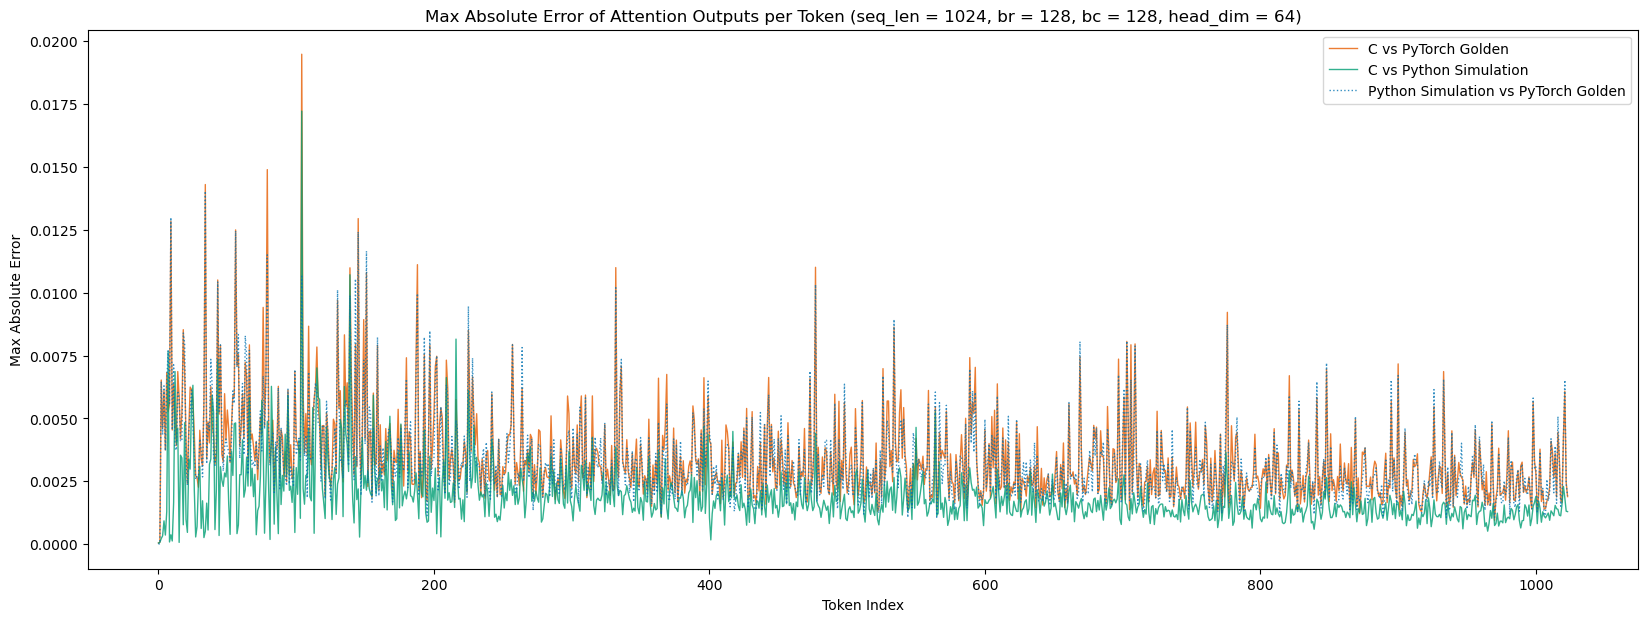

In [7]:
plt.figure(figsize=(20, 7))
plt.plot(O_c["seq1024_brbc128x128"].max_abs_error(O_golden["seq1024_brbc128x128"])[1],
         label="C vs PyTorch Golden",
         linewidth=1.0,
         alpha=0.8,
         color="#E65C00")
plt.plot(O_c["seq1024_brbc128x128"].max_abs_error(O_python["seq1024_brbc128x128"])[1],
         label="C vs Python Simulation",
         linewidth=1.0, 
         alpha=0.8,
         color="#009E73")
plt.plot(O_python["seq1024_brbc128x128"].max_abs_error(O_golden["seq1024_brbc128x128"])[1],
         label="Python Simulation vs PyTorch Golden",
         linewidth=1.0,
         alpha=0.8,
         linestyle="dotted",
         color="#0072B2")
plt.xlabel("Token Index")
plt.ylabel("Max Absolute Error")
plt.title("Max Absolute Error of Attention Outputs per Token (seq_len = 1024, br = 128, bc = 128, head_dim = 64)")
plt.legend()

print(f"Tensor Level Max Absolute Error (C vs Golden) (seq_len = 1024, br = 128, bc = 128, head_dim = 64): {O_c['seq1024_brbc128x128'].max_abs_error(O_golden['seq1024_brbc128x128'])[0]:.6f}")

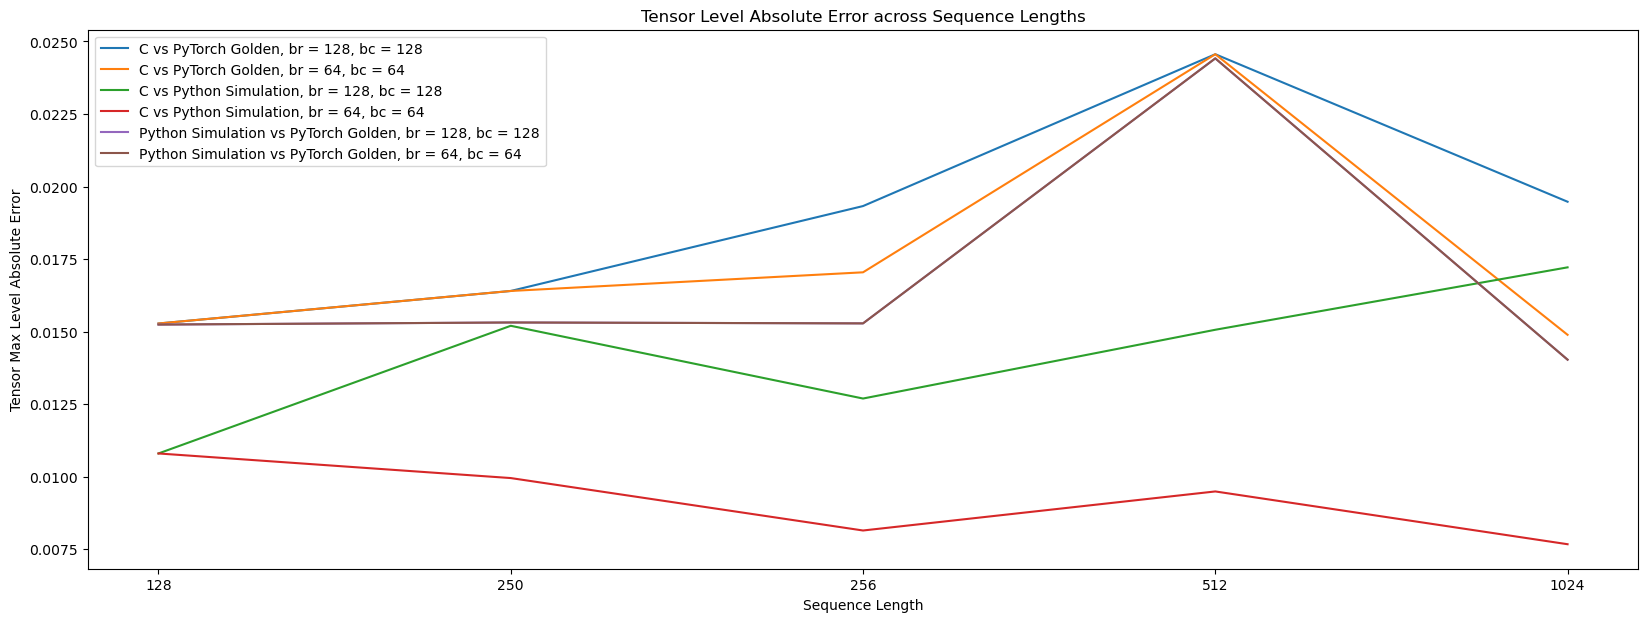

In [8]:
tensor_abs_error_c_golden_128x128 = {}
tensor_abs_error_c_golden_64x64 = {}
tensor_abs_error_c_python_128x128 = {}
tensor_abs_error_c_python_64x64 = {}
tensor_abs_error_python_golden_128x128 = {}
tensor_abs_error_python_golden_64x64 = {}

pairs = sorted(
    zip(O_c.items(), O_golden.items(), O_python.items()),
    key=lambda pair: int(pair[0][0].split("_")[0].replace("seq", ""))
)

for (k_c, v_c), (k_golden, v_golden), (k_python, v_python) in pairs:
    if "128x128" in k_c and k_c == k_golden == k_python:
        tensor_abs_error_c_golden_128x128[k_c.split("_")[0].replace("seq", "")] = v_c.max_abs_error(v_golden)[0]
        tensor_abs_error_c_python_128x128[k_c.split("_")[0].replace("seq", "")] = v_c.max_abs_error(v_python)[0]
        tensor_abs_error_python_golden_128x128[k_c.split("_")[0].replace("seq", "")] = v_python.max_abs_error(v_golden)[0]
    elif "64x64" in k_c and k_c == k_golden == k_python:
        tensor_abs_error_c_golden_64x64[k_c.split("_")[0].replace("seq", "")] = v_c.max_abs_error(v_golden)[0]
        tensor_abs_error_c_python_64x64[k_c.split("_")[0].replace("seq", "")] = v_c.max_abs_error(v_python)[0]
        tensor_abs_error_python_golden_64x64[k_c.split("_")[0].replace("seq", "")] = v_python.max_abs_error(v_golden)[0]

plt.figure(figsize=(20, 7))
plt.plot(list(tensor_abs_error_c_golden_128x128.keys()), list(tensor_abs_error_c_golden_128x128.values()),
         label="C vs PyTorch Golden, br = 128, bc = 128")
plt.plot(list(tensor_abs_error_c_golden_64x64.keys()), list(tensor_abs_error_c_golden_64x64.values()),
         label="C vs PyTorch Golden, br = 64, bc = 64")
plt.plot(list(tensor_abs_error_c_python_128x128.keys()), list(tensor_abs_error_c_python_128x128.values()),
         label="C vs Python Simulation, br = 128, bc = 128")
plt.plot(list(tensor_abs_error_c_python_64x64.keys()), list(tensor_abs_error_c_python_64x64.values()),
         label="C vs Python Simulation, br = 64, bc = 64")
plt.plot(list(tensor_abs_error_python_golden_128x128.keys()), list(tensor_abs_error_python_golden_128x128.values()),
         label="Python Simulation vs PyTorch Golden, br = 128, bc = 128")
plt.plot(list(tensor_abs_error_python_golden_64x64.keys()), list(tensor_abs_error_python_golden_64x64.values()),
         label="Python Simulation vs PyTorch Golden, br = 64, bc = 64")
plt.xlabel("Sequence Length")
plt.ylabel("Tensor Max Level Absolute Error")
plt.title("Tensor Level Absolute Error across Sequence Lengths")
plt.legend()

### 3. Outputs Distribution

Sequence Length为1k，Br = Bc = 128情况下的输出数据分布情况

The max, min and mean value of C output (seq_len = 1024, br = 128, bc = 128, head_dim = 64): max=3.707300, min=-2.321600, mean=0.003511
The max, min and mean value of PyTorch Golden output (seq_len = 1024, br = 128, bc = 128, head_dim = 64): max=3.707251, min=-2.321620, mean=0.003513


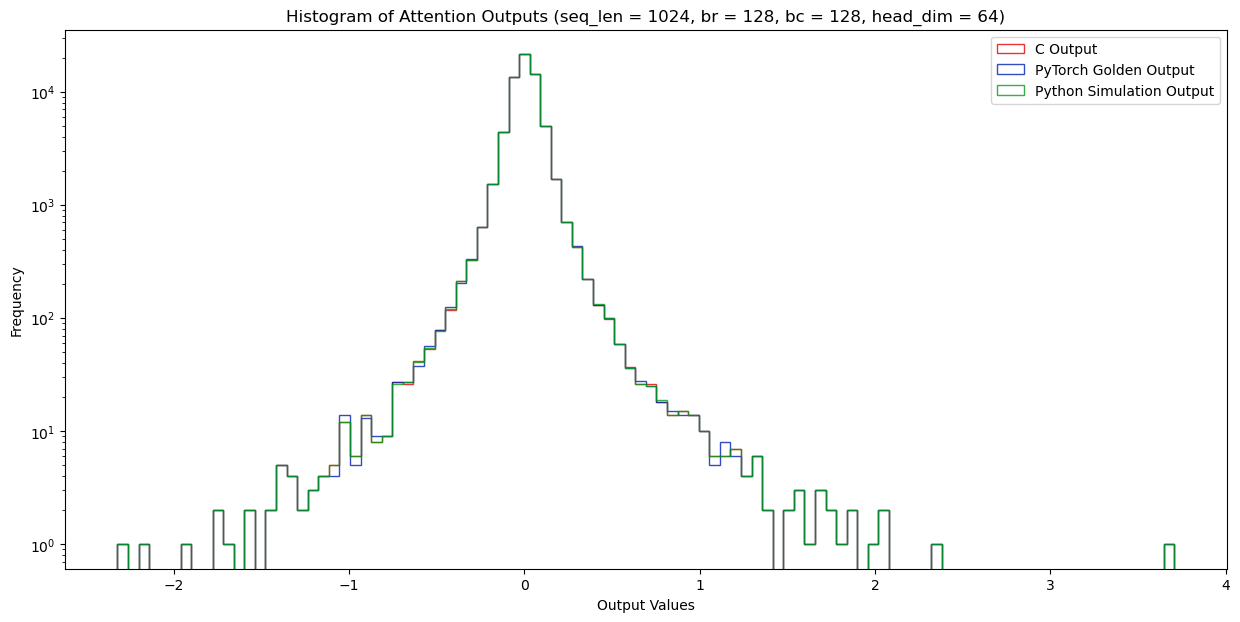

In [9]:
plt.figure(figsize=(15, 7))
plt.hist(O_c["seq1024_brbc128x128"].tensor.flatten().numpy(), 
         bins=100, 
         alpha=0.8, 
         label="C Output", 
         color="#E60000",
         log=True,
         histtype="step")
plt.hist(O_golden["seq1024_brbc128x128"].tensor.flatten().numpy(), 
         bins=100, 
         alpha=0.8, 
         label="PyTorch Golden Output", 
         color="#0021B2",
         log=True,
         histtype="step")
plt.hist(O_python["seq1024_brbc128x128"].tensor.flatten().numpy(), 
         bins=100, 
         alpha=0.8, 
         label="Python Simulation Output", 
         color="#009E15",
         log=True,
         histtype="step")
plt.xlabel("Output Values")
plt.ylabel("Frequency")
plt.title("Histogram of Attention Outputs (seq_len = 1024, br = 128, bc = 128, head_dim = 64)")
plt.legend()

print(f"The max, min and mean value of C output (seq_len = 1024, br = 128, bc = 128, head_dim = 64): max={O_c['seq1024_brbc128x128'].tensor.max().item():.6f}, min={O_c['seq1024_brbc128x128'].tensor.min().item():.6f}, mean={O_c['seq1024_brbc128x128'].tensor.mean().item():.6f}")
print(f"The max, min and mean value of PyTorch Golden output (seq_len = 1024, br = 128, bc = 128, head_dim = 64): max={O_golden['seq1024_brbc128x128'].tensor.max().item():.6f}, min={O_golden['seq1024_brbc128x128'].tensor.min().item():.6f}, mean={O_golden['seq1024_brbc128x128'].tensor.mean().item():.6f}")